In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
datapath = r'D:\2025-2026\HK2-2025-2026\CS114\DoAn\parkinsons+telemonitoring\parkinsons_updrs.data'
df = pd.read_csv(datapath)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5875, 22)


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


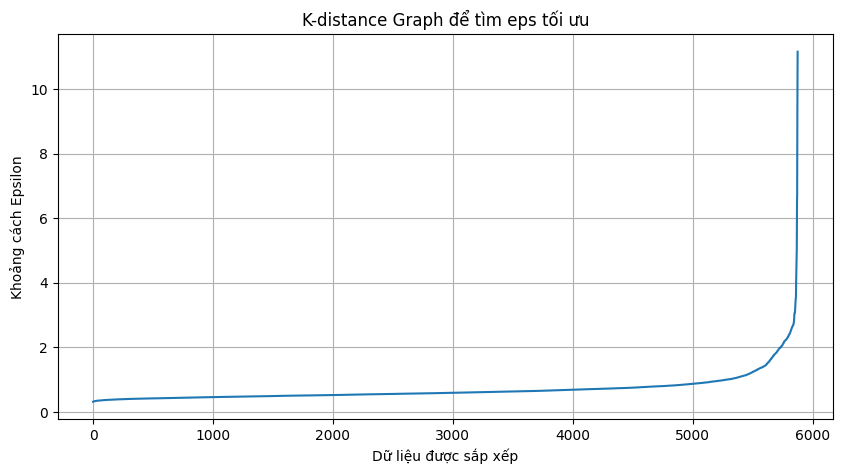

Số lượng mẫu trong mỗi cụm:
Cluster_ID
 0    5711
-1     148
 1      16
Name: count, dtype: int64


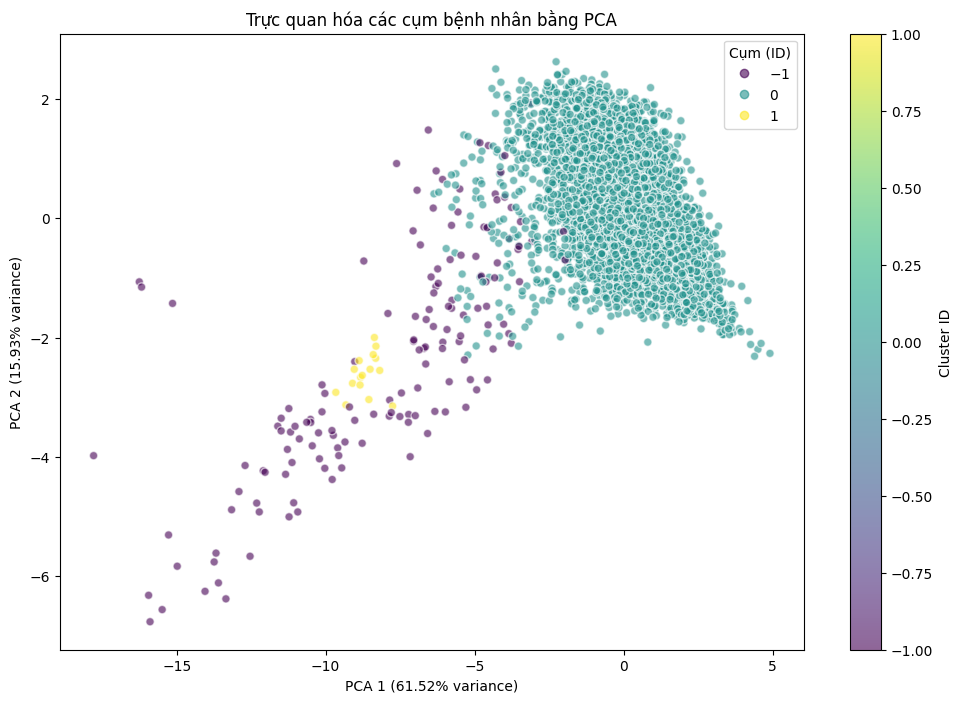


Đặc trưng trung bình của từng cụm:
            total_UPDRS  motor_UPDRS       NHR        HNR      RPDE       DFA  \
Cluster_ID                                                                      
-1            30.501155    23.034092  0.314153   8.889662  0.714810  0.642429   
 0            28.978481    21.246781  0.024021  22.053164  0.536573  0.653641   
 1            29.750688    22.870812  0.314165   6.609125  0.687011  0.609981   

                 PPE  Jitter(avg)  Shimmer(avg)  
Cluster_ID                                       
-1          0.416745     0.021106      0.306447  
 0          0.213653     0.003802      0.070187  
 1          0.514685     0.020919      0.339954  


In [4]:
# 1. Load và Tiền xử lý dữ liệu (Dựa trên EDA của bạn)
# Giả sử df là DataFrame đã load từ file parkinsons_updrs.data
# df = pd.read_csv('parkinsons_updrs.data')

# Gộp nhóm Jitter và Shimmer như bạn đã làm
df['Jitter(avg)'] = df[['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']].mean(axis=1)
df['Shimmer(avg)'] = df[['Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']].mean(axis=1)

# Chọn các đặc trưng âm thanh làm đầu vào cho phân cụm (không dùng UPDRS)
features_audio = ['NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'Jitter(avg)', 'Shimmer(avg)']
X = df[features_audio]

# 2. Chuẩn hóa dữ liệu (Bắt buộc đối với DBSCAN vì thuật toán dựa trên khoảng cách)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Tìm tham số eps tối ưu (K-distance Graph)
# DBSCAN rất nhạy cảm với tham số eps. Đoạn code này giúp tìm điểm 'khuỷu tay' (elbow)
neighbors = NearestNeighbors(n_neighbors=14) # n_neighbors thường chọn = 2 * số lượng features
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph để tìm eps tối ưu')
plt.xlabel('Dữ liệu được sắp xếp')
plt.ylabel('Khoảng cách Epsilon')
plt.grid(True)
plt.show()

# 4. Thực hiện DBSCAN
# Lưu ý: Bạn cần điều chỉnh eps dựa trên biểu đồ K-distance ở trên (thường là điểm bắt đầu dốc lên)
# Ở đây tôi ví dụ eps=1.5 và min_samples=10
dbscan = DBSCAN(eps=1.5, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

# Thêm cột Cluster ID vào dataframe gốc
df['Cluster_ID'] = clusters

# In kết quả số lượng điểm trong mỗi cụm (-1 là nhiễu/outliers)
print("Số lượng mẫu trong mỗi cụm:")
print(df['Cluster_ID'].value_counts())

# 5. Trực quan hóa bằng PCA (Giảm xuống 2D để vẽ biểu đồ)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, edgecolors='w')
plt.title('Trực quan hóa các cụm bệnh nhân bằng PCA')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(*scatter.legend_elements(), title="Cụm (ID)")
plt.colorbar(label='Cluster ID')
plt.show()

# 6. Phân tích đặc trưng của từng cụm (Profiling)
# Xem xét sự khác biệt giữa các cụm về mức độ nặng nhẹ (UPDRS) dù không dùng nó để train
cluster_profile = df.groupby('Cluster_ID')[['total_UPDRS', 'motor_UPDRS'] + features_audio].mean()
print("\nĐặc trưng trung bình của từng cụm:")
print(cluster_profile)

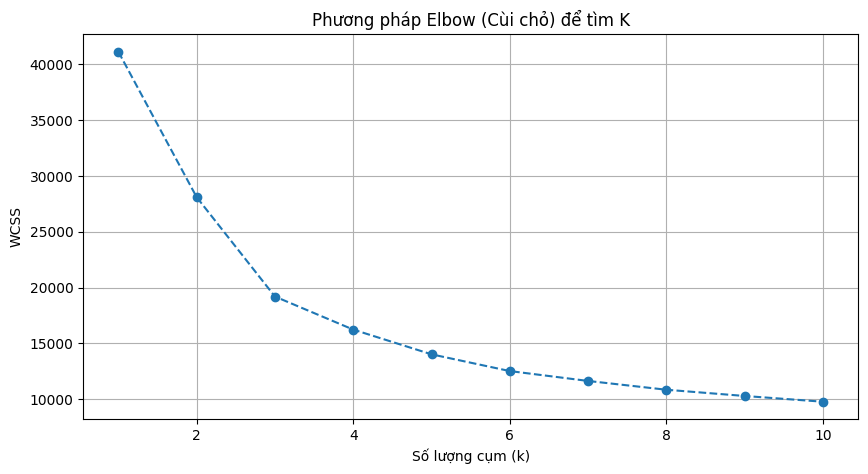

Số lượng bệnh nhân trong mỗi cụm (k=2):
KMeans_Cluster
1    5638
0     237
Name: count, dtype: int64


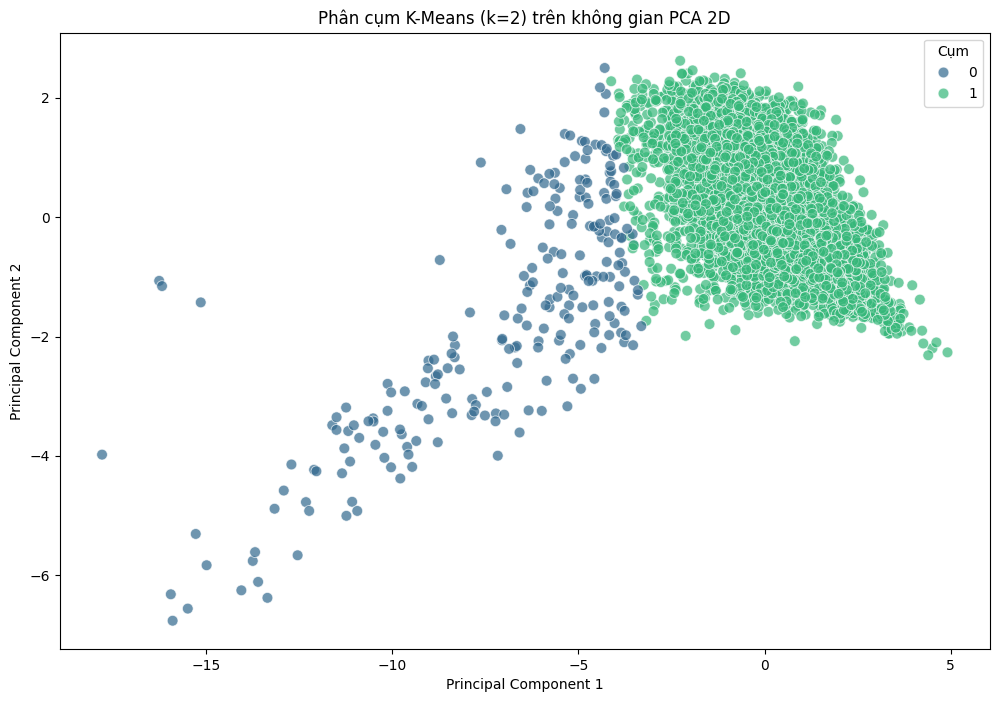


Bảng đặc trưng trung bình theo từng cụm:
                total_UPDRS  motor_UPDRS       NHR        HNR      RPDE  \
KMeans_Cluster                                                            
0                 31.437446    23.896631  0.259675  10.049861  0.704940   
1                 28.917278    21.186918  0.022554  22.168361  0.534601   

                     DFA       PPE  Jitter(avg)  Shimmer(avg)  
KMeans_Cluster                                                 
0               0.649711  0.434906     0.018423      0.275438  
1               0.653388  0.210538     0.003690      0.068527  


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Tiền xử lý dữ liệu (Đồng bộ với các bước EDA của bạn)
# df = pd.read_csv('parkinsons_updrs.data')

# Gộp nhóm Jitter và Shimmer (giảm đa cộng tuyến)
df['Jitter(avg)'] = df[['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']].mean(axis=1)
df['Shimmer(avg)'] = df[['Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']].mean(axis=1)

# Chọn các đặc trưng âm thanh (Features)
features_audio = ['NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'Jitter(avg)', 'Shimmer(avg)']
X = df[features_audio]

# 2. Chuẩn hóa dữ liệu (K-Means cực kỳ nhạy cảm với scale dữ liệu)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Phương pháp Elbow để tìm số lượng cụm (k) tối ưu
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Phương pháp Elbow (Cùi chỏ) để tìm K')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 4. Thực hiện K-Means với k tối ưu (Giả sử chọn k=3 dựa trên biểu đồ)
k_optimal = 2 
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Số lượng bệnh nhân trong mỗi cụm (k={k_optimal}):")
print(df['KMeans_Cluster'].value_counts())

# 5. Trực quan hóa kết quả bằng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['KMeans_Cluster'], 
                palette='viridis', s=60, alpha=0.7)
plt.title(f'Phân cụm K-Means (k={k_optimal}) trên không gian PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cụm')
plt.show()

# 6. Giải thích ý nghĩa các cụm (Phenotype Profiling)
# Tính trung bình điểm UPDRS để xem các cụm tương ứng với mức độ bệnh nào
profile = df.groupby('KMeans_Cluster')[['total_UPDRS', 'motor_UPDRS'] + features_audio].mean()
print("\nBảng đặc trưng trung bình theo từng cụm:")
print(profile)